Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



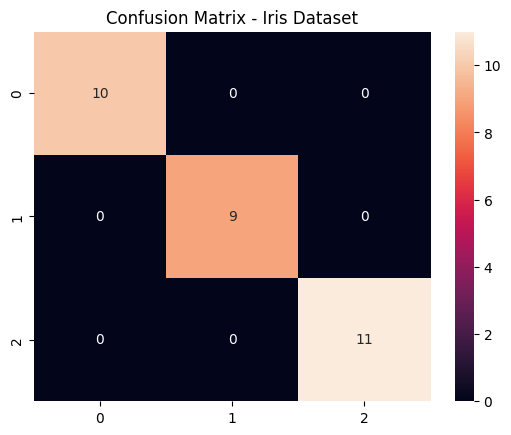

In [1]:
# KNN Classifier for IRIS Dataset
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
iris = pd.read_csv("iris.csv")

# Features and target
X = iris.drop("species", axis=1)   # change if target column name differs
y = iris["species"]

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
k = 5
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Iris Dataset")
plt.show()

In [2]:
# KNN Classifier for Diabetes Dataset (With Feature Scaling)
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
diabetes = pd.read_csv("diabetes.csv")

# Features and target
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN Model
k = 7
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6818181818181818
Confusion Matrix:
 [[78 21]
 [28 27]]


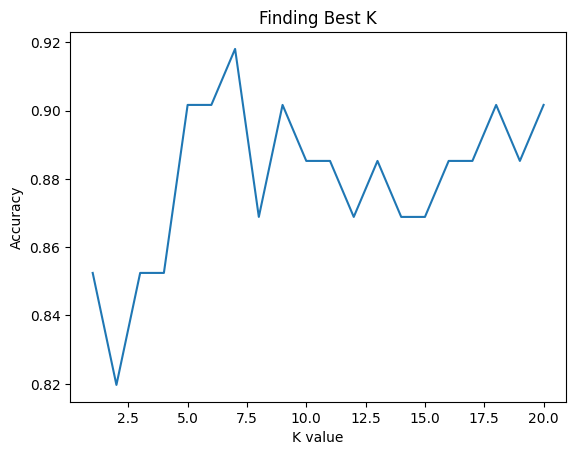

Best K: 7
Accuracy: 0.9180327868852459
Confusion Matrix:
 [[27  2]
 [ 3 29]]


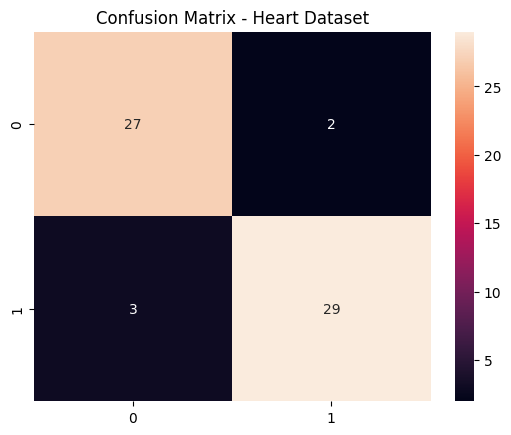

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [3]:
# KNN Classifier for Heart Dataset (Finding Best K)
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
heart = pd.read_csv("heart.csv")

# Features and target
X = heart.drop("target", axis=1)
y = heart["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find best K
scores = []

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

# Plot K vs Accuracy
plt.plot(range(1,21), scores)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Finding Best K")
plt.show()

# Best K
best_k = scores.index(max(scores)) + 1
print("Best K:", best_k)

# Train final model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Heart Dataset")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))